In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print("Ready for Project 4!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JERIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JERIN\AppData\Roaming\nltk_data...


Ready for Project 4!


[nltk_data]   Unzipping tokenizers\punkt.zip.


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

positive_reviews = [
    "This product is amazing and wonderful",
    "I absolutely love this item great quality",
    "Excellent purchase very happy with it",
    "Best product ever highly recommend",
    "Outstanding quality and fast delivery",
    "Really satisfied with this purchase",
    "Great value for money loved it",
    "Perfect product works exactly as described",
    "Superb quality will buy again",
    "Fantastic experience very pleased",
]

negative_reviews = [
    "This product is terrible waste of money",
    "Very disappointed with the quality",
    "Worst purchase ever do not buy",
    "Completely useless and broken",
    "Poor quality stopped working quickly",
    "Very bad experience never again",
    "Horrible product not worth it",
    "Defective item very unhappy",
    "Terrible quality very disappointed",
    "Awful product waste of time",
]

neutral_reviews = [
    "Product is okay nothing special",
    "Average quality meets expectations",
    "It is fine does what it should",
    "Neither good nor bad just average",
    "Decent product for the price",
    "Works as expected nothing more",
    "Okay product not great not bad",
    "Fair quality average performance",
    "Satisfactory product meets basic needs",
    "Acceptable quality for the price",
]

reviews = positive_reviews * 50 + negative_reviews * 50 + neutral_reviews * 50
sentiments = ['Positive'] * 500 + ['Negative'] * 500 + ['Neutral'] * 500

df = pd.DataFrame({
    'Review': reviews,
    'Sentiment': sentiments
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv('sentiment_data.csv', index=False)

print("Dataset created!")
print("Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())
print(df.head())

Dataset created!
Shape: (1500, 2)

Sentiment Distribution:
Sentiment
Neutral     500
Positive    500
Negative    500
Name: count, dtype: int64
                                      Review Sentiment
0             Okay product not great not bad   Neutral
1     Satisfactory product meets basic needs   Neutral
2      Excellent purchase very happy with it  Positive
3         Best product ever highly recommend  Positive
4  I absolutely love this item great quality  Positive


In [3]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['Review'].apply(clean_text)

print("Text cleaned!")
print(df[['Review', 'clean_text']].head())

Text cleaned!
                                      Review  \
0             Okay product not great not bad   
1     Satisfactory product meets basic needs   
2      Excellent purchase very happy with it   
3         Best product ever highly recommend   
4  I absolutely love this item great quality   

                               clean_text  
0                  okay product great bad  
1  satisfactory product meets basic needs  
2                excellent purchase happy  
3      best product ever highly recommend  
4      absolutely love item great quality  


In [4]:
X = df['clean_text']
y = df['Sentiment']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42)

print("Features created!")
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Features created!
Training size: (1200, 69)
Testing size: (300, 69)


In [5]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       101
     Neutral       1.00      1.00      1.00        92
    Positive       1.00      1.00      1.00       107

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



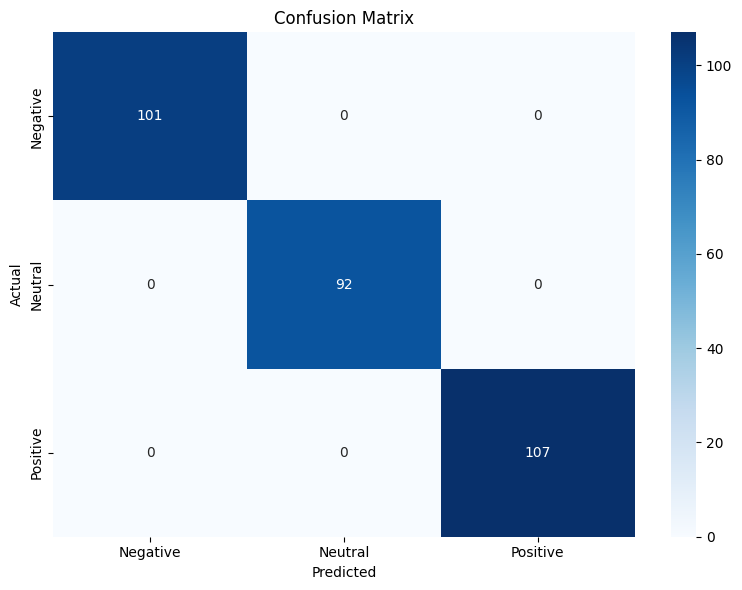

Chart saved!


In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Chart saved!")

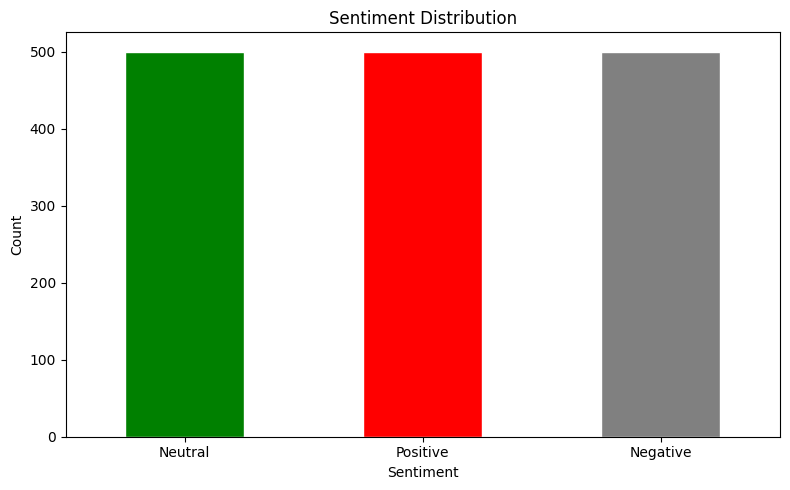

Chart saved!


In [7]:
plt.figure(figsize=(8, 5))
df['Sentiment'].value_counts().plot(
    kind='bar',
    color=['green', 'red', 'gray'],
    edgecolor='white')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_dist.png')
plt.show()
print("Chart saved!")

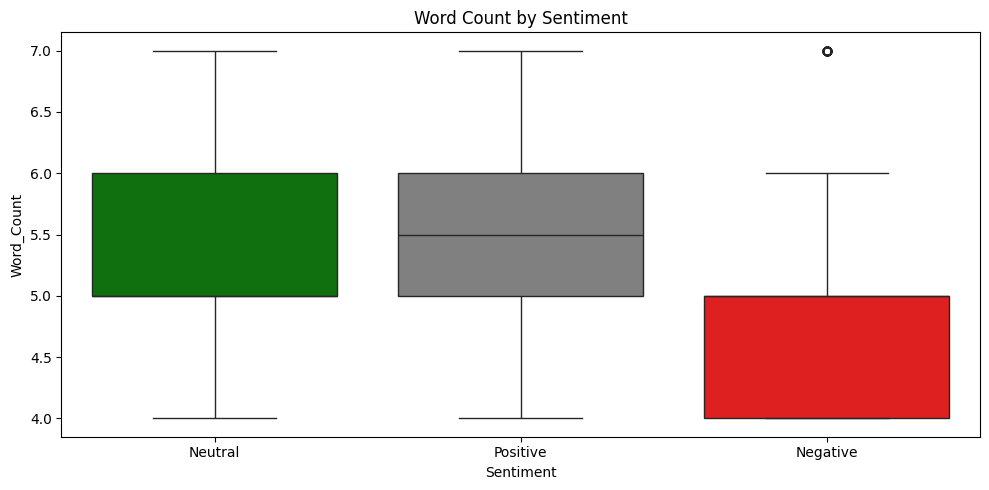

Chart saved!


In [8]:
df['Word_Count'] = df['Review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Sentiment', y='Word_Count',
            palette=['green', 'gray', 'red'])
plt.title('Word Count by Sentiment')
plt.tight_layout()
plt.savefig('word_count.png')
plt.show()
print("Chart saved!")

In [9]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

test_reviews = [
    "This product is absolutely amazing!",
    "Terrible quality waste of money",
    "It is okay nothing special"
]

print("=== TESTING NEW REVIEWS ===")
for review in test_reviews:
    sentiment = predict_sentiment(review)
    print(f"Review   : {review}")
    print(f"Sentiment: {sentiment}")
    print()

=== TESTING NEW REVIEWS ===
Review   : This product is absolutely amazing!
Sentiment: Positive

Review   : Terrible quality waste of money
Sentiment: Negative

Review   : It is okay nothing special
Sentiment: Neutral



In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("========== PROJECT 4 SUMMARY ==========")
print(f"Total Reviews     : {len(df)}")
print(f"Positive Reviews  : {len(df[df['Sentiment']=='Positive'])}")
print(f"Negative Reviews  : {len(df[df['Sentiment']=='Negative'])}")
print(f"Neutral Reviews   : {len(df[df['Sentiment']=='Neutral'])}")
print(f"Model Accuracy    : {accuracy*100:.2f}%")
print()
print("Charts saved:")
print("✅ Confusion Matrix")
print("✅ Sentiment Distribution")
print("✅ Word Count Analysis")
print("========================================")
print("Project 4 Complete!")

========== PROJECT 4 SUMMARY ==========
Total Reviews     : 1500
Positive Reviews  : 500
Negative Reviews  : 500
Neutral Reviews   : 500
Model Accuracy    : 100.00%

Charts saved:
✅ Confusion Matrix
✅ Sentiment Distribution
✅ Word Count Analysis
Project 4 Complete!
